# TEM Structural Memory Report — Arena-Struct

**Evidence-coverage report: behavioral + MEC/LEC/HPC diagnostic slice.**
Not a complete structural-memory validation (see §11 for gaps).

> **Report type:** Internal scientific evidence audit.
> **Scientific question:** Does the TEM checkpoint exhibit evidence of
> Tolman–Eichenbaum-style structural memory?
> **Current scope:** Behavioral prediction (Arena replay) + MEC structural
> diagnostics + LEC content-selectivity diagnostics + HPC binding/place-like
> diagnostics.
> **Not yet covered:** Training convergence evidence, retrieval-pathway
> analysis, remapping/generalization tests, shuffle baselines, ablations.

This report evaluates the current report-backed evidence for TEM-style
structural memory by inspecting behavioural prediction, MEC/g structural
states, LEC/x content states, and HPC/p binding-related states.  The current
evidence supports a diagnostic slice of the g/x/p factorisation, while
training dynamics, formal remapping/generalisation, ablations, shuffle
baselines, and explicit retrieval-pathway analyses remain open.

## 1. Report Identity

| Field | Value |
|---|---|
| Model family | TEM v1 (primary), TEM v2 (comparison) |
| Checkpoint | `checkpoints/tem-v1/eval-weights-only.pt` (step 10,000) |
| Task | Arena (next-observation prediction) |
| Split | `test` |
| Eval slice | 4 diagnostic cases (`arena_n4`) |
| ReportRun root | `artifacts/reports/tem_v1/arena_n4` |
| Eval artifact root | `artifacts/evaluation/tem_v1/arena_n4` |
| Git commit | Not recorded in provenance |
| Created | 2026-06-02T07:29:25Z |
| Device / precision | CPU (diagnostic regime) |
| SHA256 | Not recorded in provenance |
| Seed | Not recorded in provenance |

> **Reproducibility gap:** Git commit, checkpoint SHA256, and random seed
> are not recorded. See §12 for details.

## 2. Scientific Question

> Does the TEM model learn a reusable structural representation of
> environment topology, separable from sensory content, in the sense
> described by the Tolman–Eichenbaum Machine (Whittington et al., 2020)?

We inspect four internal pathways (detailed in §4) to evaluate evidence at
four levels:

| Level | Evidence required | Current status |
|---|---|---|
| **Behavioral** | Does the model solve the next-observation prediction task? | ✅ Available |
| **Predictive** | Are predictions topologically meaningful (better on revisits)? | ✅ Available |
| **Latent geometry** | Does MEC `g` encode structure, LEC `x` encode content? | ✅ Partial (MEC + LEC available; conjunctive HPC pending) |
| **Neural-style diagnostics** | Do units show place-like, grid-like, or landmark-like tuning? | ✅ Partial (MEC + HPC + LEC content available) |

> **Scope warning:** This report covers behavioral prediction, MEC structural
> diagnostics, LEC content-selectivity diagnostics, and HPC place-like
> diagnostics. It does **not** yet cover retrieval-pathway analysis,
> remapping/generalization, shuffle baselines, or ablations. See §11 for
> the full gap list.

## 3. Task and Benchmark — Arena Replay

Arena is a structural-navigation task where an agent navigates a 2-D grid
dungeon topology. At each step the agent occupies one passable cell and
observes a categorical **observation ID** (a unique integer per cell).
The agent can move in four cardinal directions (↑↓←→).

**Prediction task:** At each step $t$, the model receives the previous
observation ID and the action taken, and must predict the observation ID
at $t+1$.

**Revisit definition:** A **revisit** occurs when the agent occupies a cell
it has already visited earlier in the same episode. High accuracy on revisit
steps is **consistent with** structural memory, but does not by itself prove
grid-like or hippocampal-like representations.

### Benchmark Parameters (4-case diagnostic slice)

| Parameter | Value |
|---|---|
| Task family | `arena` |
| Observation classes | 45 |
| Actions | 4 (cardinal) |
| Trajectory length | 600 steps / episode |
| Grid shape (case 0) | 46 × 42 |
| Locations (case 0) | 1,932 |
| Revisits (case 0) | 557 |
| Cases in this slice | 4 (diagnostic, not full benchmark) |
| Split | `test` |
| Chance baseline | $1/45 \approx 0.022$ |

## 4. Model Internals Inspected

The TEM architecture separates structural knowledge (MEC-like) from sensory
content (LEC-like) via a conjunctive hippocampal (HPC) binding. This report
inspects the following internal variables and pathways:

| System | Scientific role | Trace | Report-facing name | Evidence section |
|---|---|---|---|---|
| MEC / `g` | Structural state, path integration | `diagnostic/mec/location_mean` | MEC structural state | §8 — MEC structural diagnostics |
| LEC / `x` | Sensory-content state | `diagnostic/lec/cells` | LEC content-state activity | §10 — LEC content diagnostics |
| LEC filtered | Secondary diagnostic transform | `diagnostic/lec/filtered` | LEC filtered diagnostic state | §10 — caveated |
| HPC / `p` | Structure-content binding | `diagnostic/hpc/location_mean` | HPC binding/place-like state | §9 — HPC binding diagnostics |
| Output | Behavioral prediction (3 pathways) | `pred/observation_id/*` | Prediction argmax per pathway | §7 — Example predictions |
| Target | Ground-truth observation sequence | `target/observation_id` | Target observation IDs | §6 — Behavioral performance |

> **Note:** LEC traces (`diagnostic/lec/cells`, `diagnostic/lec/filtered`)
> are now collected and report-backed.  The filtered trace is included
> descriptively but not interpreted as object-trace persistence (see §10).

In [1]:
from ehc_sn.reporting import open_report
from IPython.display import Image, Markdown, display

# Report paths
TEM_V1_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1"
TEM_V2_REPORT_PATH = "/home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1"

# Load reports
primary_report = open_report(TEM_V1_REPORT_PATH)
diagnostic_report = open_report(TEM_V2_REPORT_PATH)

print(f"TEM v1 report:   {primary_report.root}")
print(f"TEM v2 report:   {diagnostic_report.root}")
print(f"TEM v1 metrics:  {primary_report.summary()['metric_count']}")
print(f"TEM v2 metrics:  {diagnostic_report.summary()['metric_count']}")
print(f"TEM v1 figures:  {primary_report.summary()['figure_count']}")
print(f"TEM v2 figures:  {diagnostic_report.summary()['figure_count']}")

TEM v1 report:   /home/borja/ehc-sn/artifacts/reports/tem_v1/arena_n1
TEM v2 report:   /home/borja/ehc-sn/artifacts/reports/tem_v2/arena_n1
TEM v1 metrics:  2
TEM v2 metrics:  2
TEM v1 figures:  16
TEM v2 figures:  16


## 5. Training Dynamics and Checkpoint Selection

| Field | Status |
|---|---|
| ReportRun-backed | ❌ Pending |
| Source needed | Training logs / TensorBoard / Lightning metrics |
| Current blocker | Training logs are not yet ingested into the ReportRun artifact |
| Interpretation constraint | Behavioral and representational results below describe the selected checkpoint (step 10,000) only. They do **not** establish convergence, and the reader cannot distinguish learned structural abstraction from overfit trajectory memorisation on this small eval slice without training curves. |

**Required diagnostics (future):**
- `train/loss`, `val/loss`
- Prediction accuracy over training steps
- Component losses (transition, observation prediction, memory/reconstruction, KL)
- Learning rate schedule
- Gradient norm history

> Until training curves are available, the checkpoint selection is
> unvalidated. Results in §§6–10 should be read as describing a single
> checkpoint, not a converged model.

## 6. Behavioral Performance

The primary metric for Arena-Struct is `accuracy_revisit` — accuracy on
steps where the agent returns to a previously visited cell. The secondary
metric is `accuracy_all` — overall next-observation prediction accuracy.

**Chance baseline:** Uniform random guessing over 45 observation classes
yields $1/45 \approx 0.022$.

### Metric Table

| Model | `accuracy_all` | `accuracy_revisit` | $n$ cases | Interpretation |
|---|---|---|---|---|
| TEM v1 | 1.0 | 1.0 | 4 | Bounded diagnostic slice; ceiling performance |
| TEM v2 | 1.0 | 1.0 | 4 | Not distinguishable from TEM v1 on this slice |
| Chance | $\sim 0.022$ | $\sim 0.022$ | — | Uniform random over 45 classes |

> **Caveat:** Both models achieve ceiling on a 4-case bounded slice. This
> confirms the evaluation pipeline is functional but does **not** discriminate
> model quality or prove structural memory. A larger benchmark suite (Arena
> full, not just diagnostic slice) is needed for meaningful comparison.

### Model comparison

> TODO: explain (not the code) but what we might expect to see from the code
> output below before we run it.

In [2]:
# Display metrics from both ReportRuns
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    metrics = report.metrics()
    print(f"\n{label}:")
    for m in metrics:
        hb = " (higher is better)" if m.higher_is_better else ""
        print(f"  {m.metric:<30s} {m.value:<8} {m.unit or '—':<10s} {hb}")

print()
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    s = report.summary()
    print(
        f"{label}: {s['model_family']}, {s['metric_count']} metrics, "
        f"{s['figure_count']} figures"
    )


TEM v1:
  accuracy_all                   1.0      ratio       (higher is better)
  accuracy_revisit               1.0      ratio       (higher is better)

TEM v2:
  accuracy_all                   1.0      ratio       (higher is better)
  accuracy_revisit               1.0      ratio       (higher is better)

TEM v1: tem-v1, 2 metrics, 16 figures
TEM v2: tem-v2, 2 metrics, 16 figures


## 7. Example Predictions

This section shows behavioral prediction overlays — per-step argmax
comparisons between ground-truth observations and three prediction pathways
(inference, retrieved, ancestral). These overlays are **prediction evidence,
not representational evidence**. MEC and HPC diagnostics appear in §§8–9.

### Arena Task Overview (Paradigm Context)

Panel (a): Dungeon topology with free cells coloured by observation ID.
Panel (b): Agent trajectory through the environment, coloured by time.
Red stars mark revisit steps.

> **What this shows:** The environment layout and agent path.
> **What this does not show:** Model predictions, latent states, or pathway
> contributions.

Arena Task Overview (case=arena_n1)


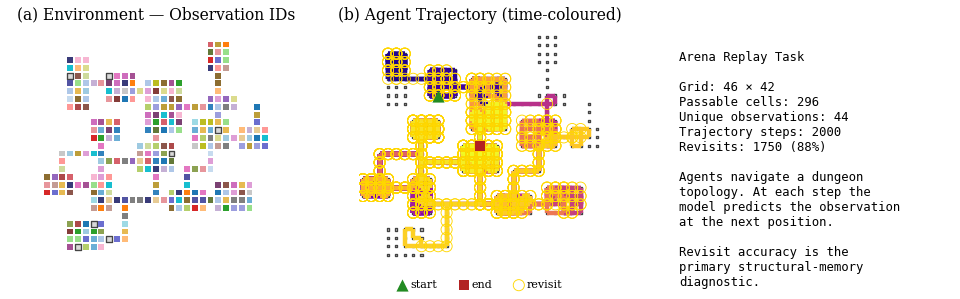

In [3]:
# Arena Task Overview (paradigm context; same dataset for both models)
overview_entry = primary_report.figure_entry(
    "arena_task_overview", preferred_format="png"
)
if overview_entry:
    abs_path = primary_report.root / overview_entry.path
    print(f"Arena Task Overview (case={overview_entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("arena_task_overview not available.")

### Arena Prediction Overlays

Ground-truth observation sequence (`gt`) vs. three prediction pathways:
- Inference pathway argmax
- Retrieved (memory) pathway argmax
- Ancestral (structural prior) pathway argmax

Mismatched cells are outlined in black.

> **What this shows:** *Which* class each pathway predicts.
> **What this does not show:** Confidence, softmax probability, logit
> margins, top-k alternatives, or pathway uncertainty.

Below is the first case's overlay figure from each ReportRun.

TEM v1 — arena_prediction_overlay (case=arena_n1)


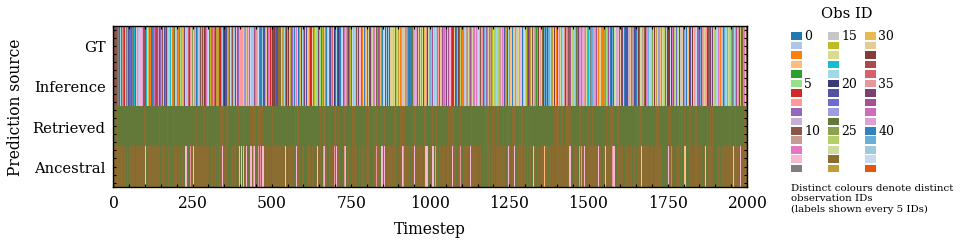


TEM v2 — arena_prediction_overlay (case=arena_n1)


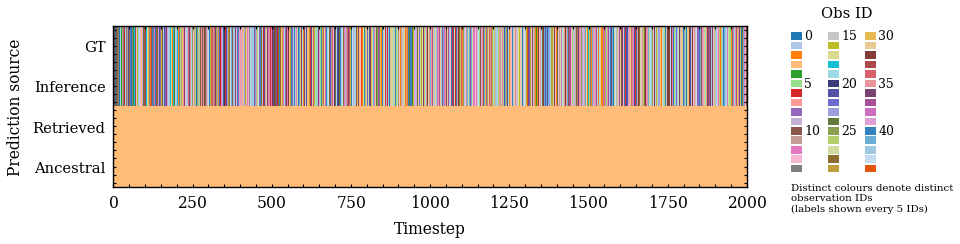

In [4]:
# --- Prediction overlay: first case from TEM v1 ---
overlay_entry = primary_report.figure_entry(
    "arena_prediction_overlay", preferred_format="png"
)
if overlay_entry:
    abs_path = primary_report.root / overlay_entry.path
    print(f"TEM v1 — {overlay_entry.figure_id} (case={overlay_entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("No arena_prediction_overlay found in TEM v1 ReportRun.")

print()

# --- Prediction overlay: first case from TEM v2 ---
overlay_entry_v2 = diagnostic_report.figure_entry(
    "arena_prediction_overlay", preferred_format="png"
)
if overlay_entry_v2:
    abs_path_v2 = diagnostic_report.root / overlay_entry_v2.path
    print(f"TEM v2 — {overlay_entry_v2.figure_id} (case={overlay_entry_v2.regime_id})")
    display(Image(filename=str(abs_path_v2)))
else:
    print("No arena_prediction_overlay found in TEM v2 ReportRun.")

In [5]:
# List all overlay entries across both reports
print("Overlay entries by case:")
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    fig_index = report.figures()
    if fig_index:
        overlays = [
            e for e in fig_index.entries if e.figure_id == "arena_prediction_overlay"
        ]
        print(f"\n{label}: {len(overlays)} overlay entries")
        for e in overlays:
            print(f"  case={e.regime_id:<12s} format={e.format:<5s} {e.path}")
    else:
        print(f"\n{label}: no figure index")

Overlay entries by case:

TEM v1: 2 overlay entries
  case=arena_n1     format=png   figures/0000-arena-test-0000-arena_prediction_overlay.png
  case=arena_n1     format=pdf   figures/0000-arena-test-0000-arena_prediction_overlay.pdf

TEM v2: 2 overlay entries
  case=arena_n1     format=png   figures/0000-arena-test-0000-arena_prediction_overlay.png
  case=arena_n1     format=pdf   figures/0000-arena-test-0000-arena_prediction_overlay.pdf


## 8. MEC / g Structural-Stream Diagnostics

This section evaluates whether the MEC-like structural state (`g`) encodes
environment topology with grid-like spatial periodicity.

| Field | Status |
|---|---|
| ReportRun-backed | ✅ Yes |
| Trace source | `diagnostic/mec/location_mean` |
| Evidence type | Rate maps, autocorrelograms, gridness metrics, grid spacing estimates |
| Statistical baseline | ❌ Pending — no shuffle or occupancy-matched null baseline |
| Interpretation | **Suggestive, not confirmatory.** Gridness scores are descriptive only. |

### Figures

- `mec_grid_metrics`: Gridness scores and grid spacing by frequency band,
  with representative autocorrelograms for top-gridness cells.
- `mec_autocorr_mosaic`: Population autocorrelogram mosaic ordered by
  gridness score per frequency band.

> **Caveat:** Gridness is reported without shuffle baselines. Without an
> occupancy-matched null distribution, these scores are descriptive rather
> than statistically validated. They are consistent with grid-cell-like
> spatial periodicity but do not establish it.

Below are the `mec_grid_metrics` and `mec_autocorr_mosaic` figures from
each ReportRun.

TEM v1 — mec_grid_metrics (case=arena_n1)


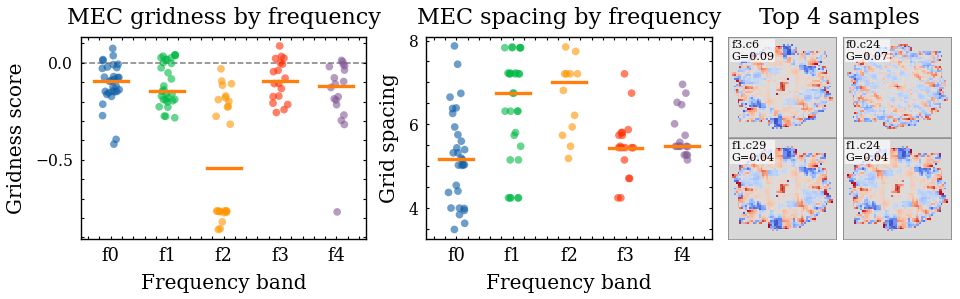


TEM v2 — mec_grid_metrics (case=arena_n1)


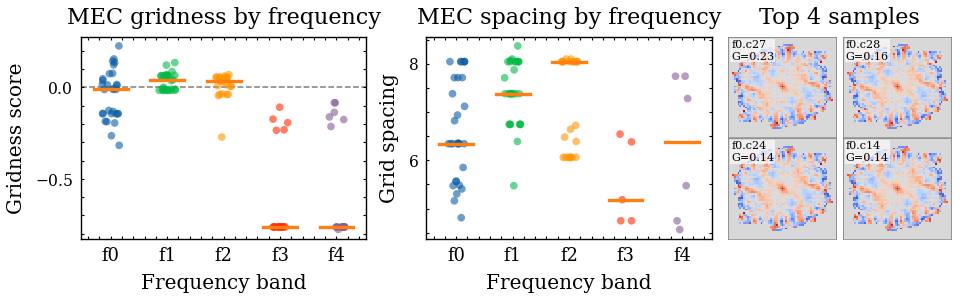

In [6]:
# --- MEC quantitative gridness metrics: first case from each ReportRun ---
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    entry = report.figure_entry("mec_grid_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_grid_metrics not available.")
    print()

TEM v1 — mec_autocorr_mosaic (case=arena_n1)


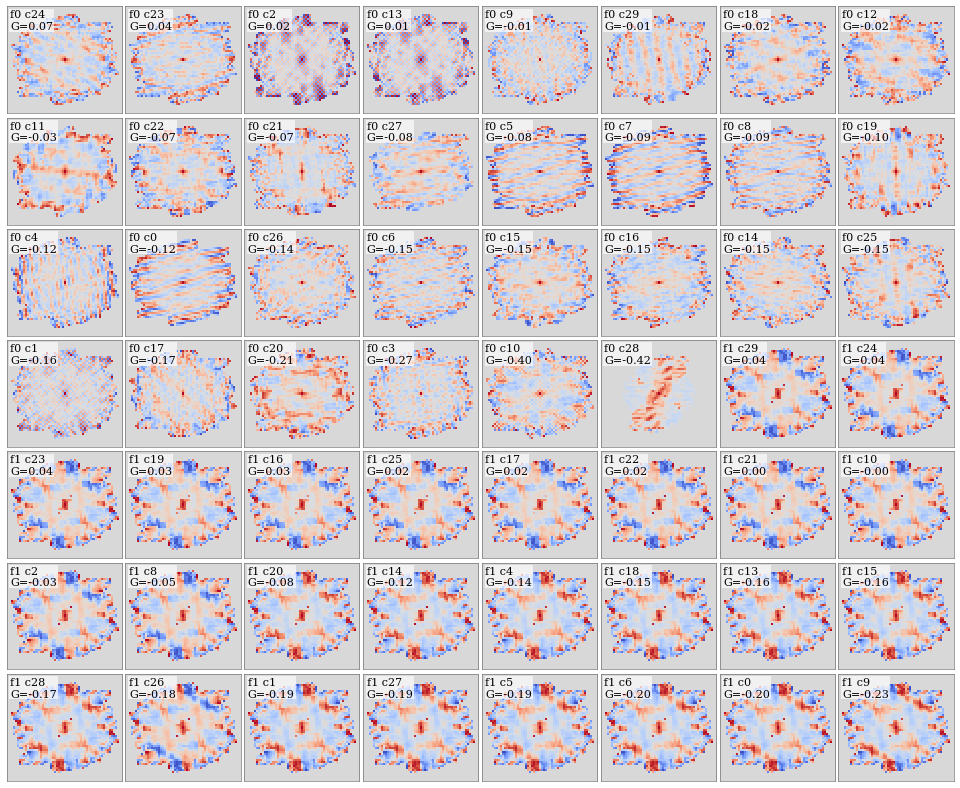


TEM v2 — mec_autocorr_mosaic (case=arena_n1)


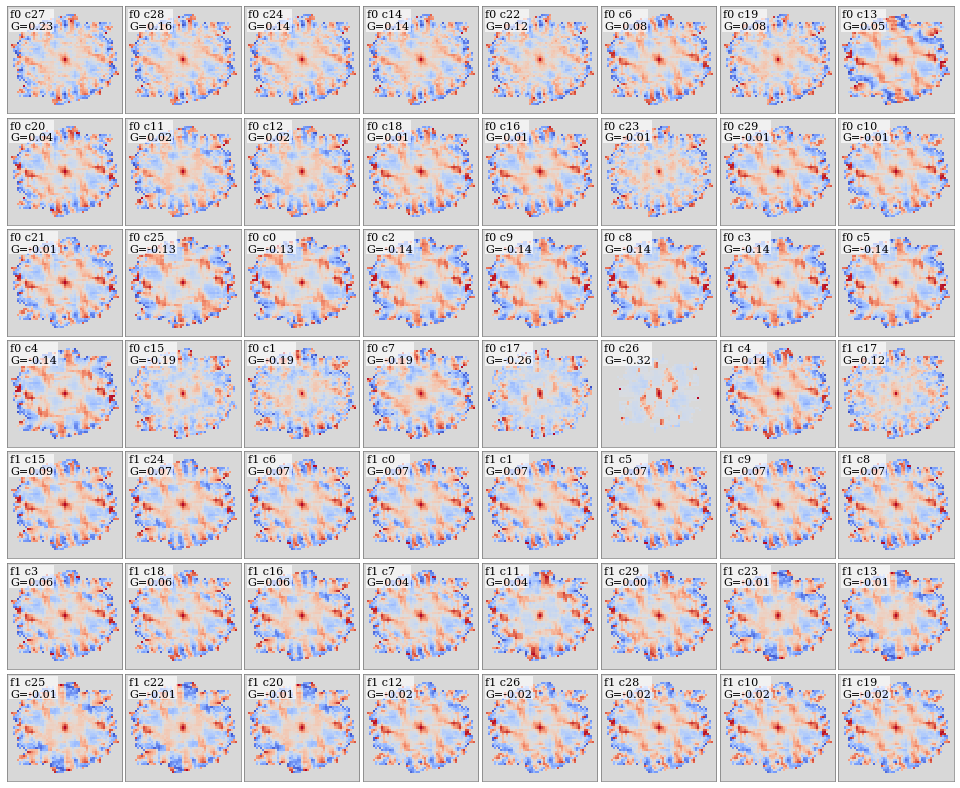

In [7]:
# --- MEC autocorrelogram mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    entry = report.figure_entry("mec_autocorr_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: mec_autocorr_mosaic not available.")
    print()

## 9. HPC / p Place and Binding Diagnostics

This section evaluates whether the hippocampal conjunctive state (`p`)
exhibits place-like spatial selectivity — localised firing to specific
positions in the environment.

| Field | Status |
|---|---|
| ReportRun-backed | ✅ Yes (place-like rate maps and spatial information) |
| Trace source | `diagnostic/hpc/location_mean` |
| Evidence type | Spatial information scores, field-center scatter, rate-map examples, population mosaic |
| Conjunctive `g`-`x` binding | ⚠️ LEC traces are now available (§10), but full conjunctive `g`/`x`/`p` analysis still requires explicit cross-stream decoding or binding diagnostics |
| Statistical baseline | ❌ Pending — no shuffle baseline for spatial information significance |
| Interpretation | Place-like spatial selectivity is present, but full conjunctive binding (TEM's central claim) is not yet established |

### Figures

- `hpc_place_metrics`: Spatial information distribution (strip plot),
  field-center locations over the arena (scatter), and top-4 rate-map
  examples (2×2 mosaic).
- `hpc_rate_map_mosaic`: Flat wrapped population survey of rate maps
  ordered by descending spatial information.

> **Caveat:** Place-like spatial selectivity is present in the available
> diagnostics, supporting rate-map localisation.  LEC content traces are now
> available, but assessing whether HPC `p` truly binds separable structural
> and content signals requires cross-stream decoding or explicit
> conjunctivity diagnostics not yet implemented.  Spatial information scores
> are reported without shuffle baselines.

Below are the `hpc_place_metrics` and `hpc_rate_map_mosaic` figures from
each ReportRun.

TEM v1 — hpc_place_metrics (case=arena_n1)


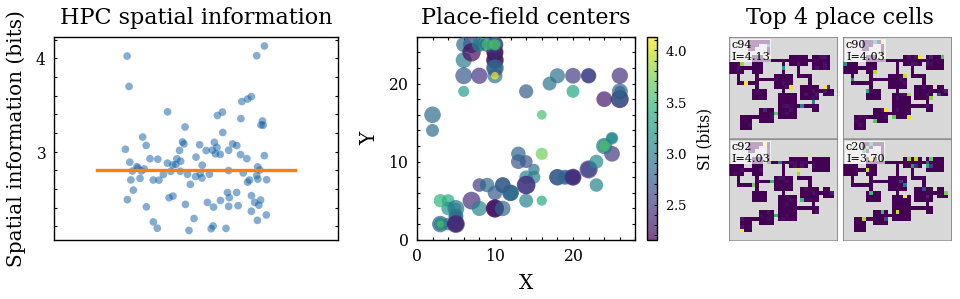


TEM v2 — hpc_place_metrics (case=arena_n1)


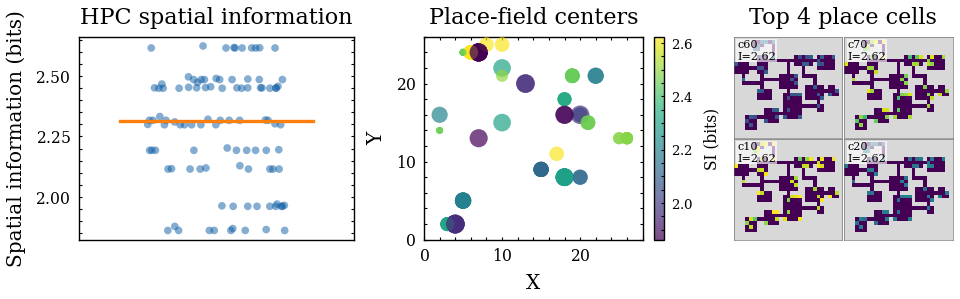

In [8]:
# --- HPC place metrics: first case from each ReportRun ---
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    entry = report.figure_entry("hpc_place_metrics", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_place_metrics not available.")
    print()

TEM v1 — hpc_rate_map_mosaic (case=arena_n1)


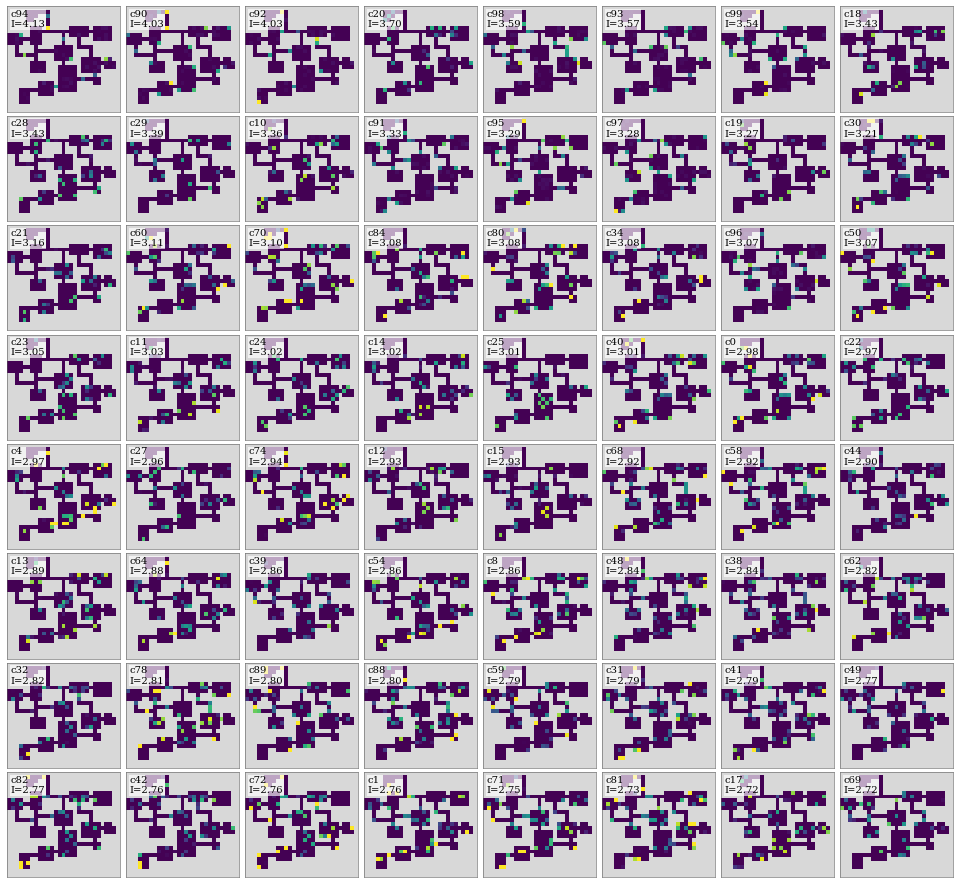


TEM v2 — hpc_rate_map_mosaic (case=arena_n1)


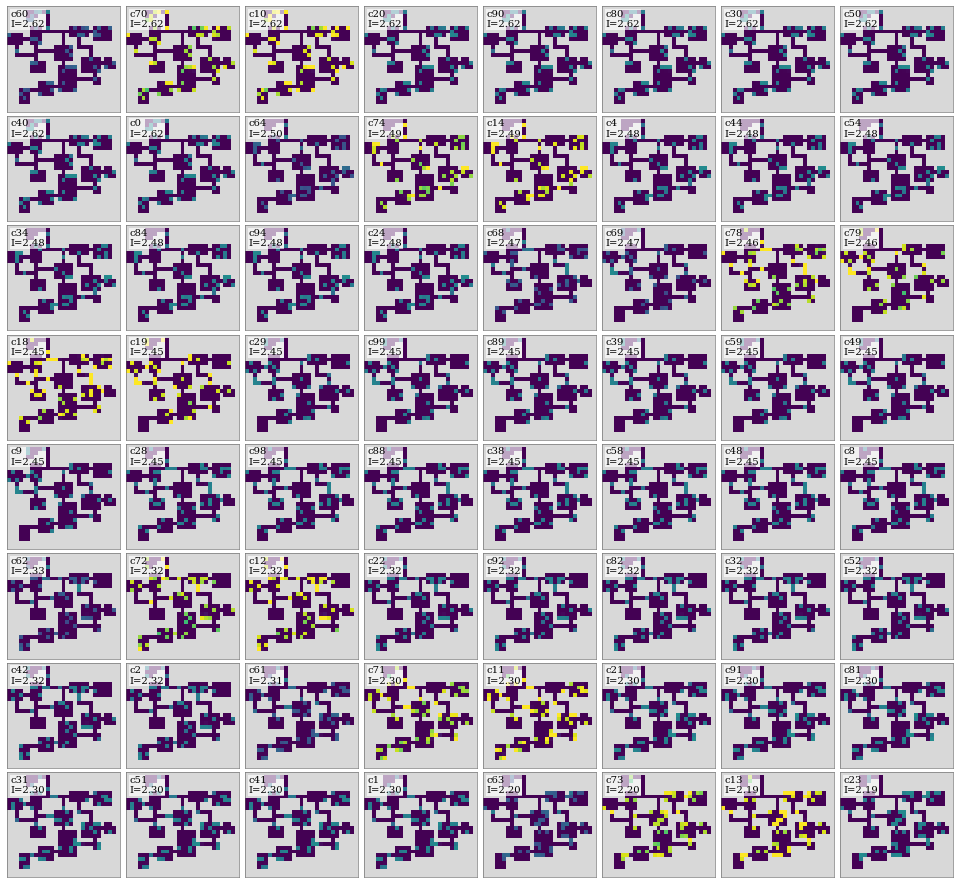

In [9]:
# --- HPC rate-map mosaic: first case from each ReportRun ---
for label, report in [("TEM v1", primary_report), ("TEM v2", diagnostic_report)]:
    entry = report.figure_entry("hpc_rate_map_mosaic", preferred_format="png")
    if entry:
        abs_path = report.root / entry.path
        print(f"{label} — {entry.figure_id} (case={entry.regime_id})")
        display(Image(filename=str(abs_path)))
    else:
        print(f"{label}: hpc_rate_map_mosaic not available.")
    print()

## 10. LEC / x Sensory-Content Diagnostics

The TEM implementation includes an explicit LEC stream that processes
observation embeddings before projection into HPC. In the
Tolman–Eichenbaum interpretation, this stream corresponds to the sensory/
content state $x$.

This section evaluates the LEC content stream in two ways. First, the
content-filtering diagnostic figure (§10a) shows LEC content-state and
filtered-state per-unit activations across frequency bands, plus the
learned retention and input-mixing gate values annotated inside each
band label. Second, the content-vs-location contrast (§10b) asks whether
LEC activity is organised more by sensory identity than by arena location,
and compares that organisation against MEC/g and HPC/p.

Together, these figures test whether LEC acts as a content-state stream
rather than another spatial-map diagnostic.

### Coverage

| Field | Status |
|---|---|
| Primary trace | `diagnostic/lec/cells` — report-backed via eval `--trace-keys` |
| Secondary trace | `diagnostic/lec/filtered` — available, semantics unconfirmed |
| Gate traces | `lec/filter/alpha_sigmoid`, `lec/w_f_sigmoid` — not yet populated in eval artifact |
| Main mechanism figure | `lec_content_filtering_diagnostic` — per-unit activation flow (3-panel stacked heatmap) |
| Main comparative figure | `lec_content_structure_rsa` — content vs. location organisation across streams |
| Not claimed | Object-trace cells, grid cells, place cells, biological LEC equivalence |
| Caveat | `filtered` semantics not yet interpreted; may be frequency decomposition, not temporal persistence |

### Figures

Below are the two LEC figures from the TEM v1 report run.  Panel labels
are visible in the images.

---

**Figure 10a: LEC / x content-state filtering.**
Three vertically stacked panels sharing the same per-unit row order and
time axis:

Panel **a** — content-state activations per unit, grouped by frequency
band (5 bands, 10 units each, arranged from f0 to f4).  Band labels in
the left margin include the frequency index and, when available, the
learned gate parameters ($\alpha_f$, $w_f$).

Panel **b** — filtered-state activations in the same row order.

Panel **c** — filter effect ($\text{filtered} - \text{content}$) with a
centred diverging colormap, highlighting which activation dimensions are
suppressed or enhanced by the frequency-dependent filtering.

This is a **model-internal activation-flow diagnostic** for the sensory/
content stream — not a biological firing-rate raster.

**Figure 10b: Content vs. location organisation across TEM streams.**
Panel **a** — observation grouping: same-vs-different observation similarity.
Panel **b** — location grouping: same-vs-different location similarity.
Panel **c** — content effect vs location effect across LEC, MEC, and HPC.

Definitions:
- *content effect* = mean similarity(same observation) − mean similarity(different observation)
- *location effect* = mean similarity(same location) − mean similarity(different location)

TEM v1 — lec_content_filtering_diagnostic (case=arena_n1)


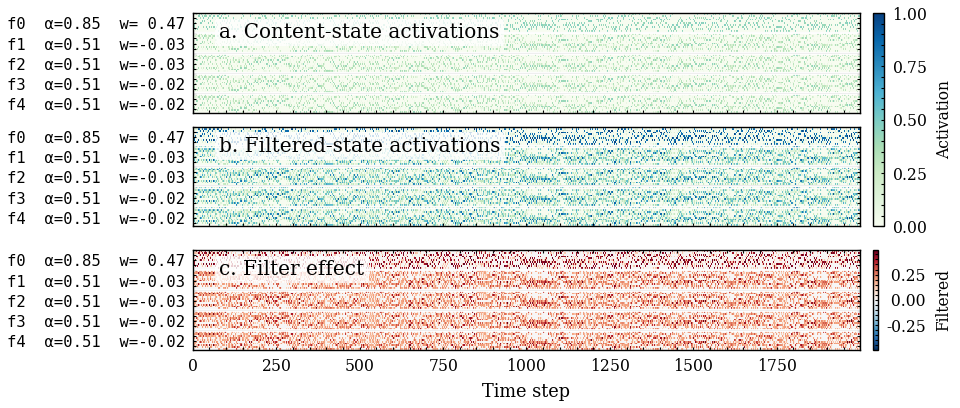

In [10]:
# Figure 10a: lec_content_filtering_diagnostic
entry = primary_report.figure_entry(
    "lec_content_filtering_diagnostic", preferred_format="png"
)
if entry:
    abs_path = primary_report.root / entry.path
    print(f"TEM v1 — {entry.figure_id} (case={entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("lec_content_filtering_diagnostic not available in TEM v1 ReportRun.")

## 11. Evidence Gaps and Next Diagnostic Steps

This section consolidates all claims that are **not yet** evaluated or
report-backed. Unlike the evidence sections above, these are not stubs —
they are explicit blocker statements grouped by missing claim.

| Missing claim | Why it matters | Current blocker | Next artifact needed |
|---|---|---|---|
| **Training convergence** | Establishes checkpoint credibility; distinguishes learned structure from overfit memorisation | Training logs not ingested | Train/val loss metric artifact |
| **Retrieval pathway** | Tests whether memory lookup (not only prediction) is correct and interpretable | Retrieval-specific traces not exposed in report | Retrieval trace fields + retrieval accuracy metrics |
| **Remapping / generalisation** | Tests whether structural codes are reusable across environments | Only single small eval slice (4 cases) available | Cross-environment eval set with sensory remapping |
| **Gridness significance** | Controls false-positive grid-cell claims | No shuffle baseline implemented | Shuffled occupancy / rate-map null distribution |
| **Place-field significance** | Controls false-positive place-like claims | No shuffle baseline for spatial information | Shuffled spatial information null distribution |
| **Ablations** | Tests causal role of MEC/LEC/HPC modules | No ablation report runs exist | MEC/LEC/HPC lesion configs + eval runs |

### Priority Order for Next Implementation

1. **Add shuffle baselines** for gridness and spatial information metrics
2. **Expose retrieval traces** and add retrieval-specific metrics
3. **Build cross-environment eval set** to test remapping / generalisation
4. **Run ablation studies** (MEC lesion, LEC lesion, no-memory variant)
5. **Ingest training logs** into ReportRun format (train/val loss curves)

---

**Figure 10b: Content vs. location organisation across TEM streams.**
Panel A — LEC similarity split by same/different observation.
Panel B — MEC similarity split by same/different location.
Panel C — content effect vs location effect for all three streams.

Definitions:
- *content effect* = mean similarity(same observation) − mean similarity(different observation)
- *location effect* = mean similarity(same location) − mean similarity(different location)

A TEM-style factorisation predicts a relative dissociation: LEC should
show stronger content organisation, MEC stronger location organisation,
and HPC may combine both.  The figure reports the measured values.



TEM v1 — lec_content_structure_rsa (case=arena_n1)


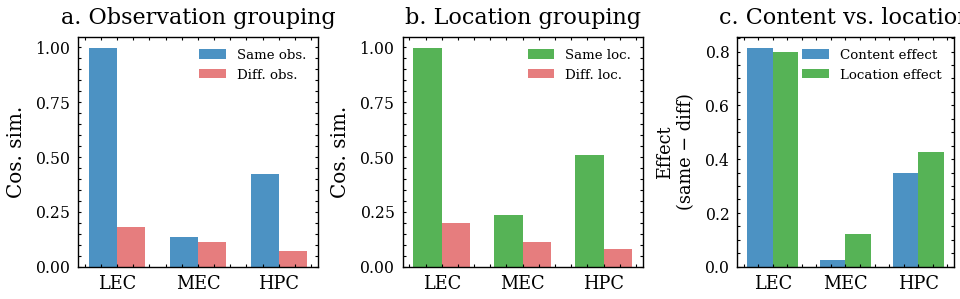

In [11]:
# Figure 10b: lec_content_structure_rsa
entry = primary_report.figure_entry(
    "lec_content_structure_rsa", preferred_format="png"
)
if entry:
    abs_path = primary_report.root / entry.path
    print(f"TEM v1 — {entry.figure_id} (case={entry.regime_id})")
    display(Image(filename=str(abs_path)))
else:
    print("lec_content_structure_rsa not available in TEM v1 ReportRun.")

### Interpretation

The content-filtering diagnostic (Figure 10a) exposes the LEC-specific
mechanism as a per-unit activation flow.  Panel **a** shows raw content-state
activations, panel **b** shows the filtered (processed) state, and panel
**c** shows the difference (filtered minus content) with a centred diverging
colormap, highlighting which activation dimensions are suppressed or enhanced
by the frequency-dependent filtering.  Band labels in the left margin of
panel **a** include the frequency index and, when available, the learned gate
parameters ($\alpha_f$, $w_f$).  When gate parameters are absent (as in this
ReportRun), the band labels show only the frequency index and a notice is
placed below the figure.  This is a model-internal activation-flow diagnostic
for the sensory/content ($x$) stream — not a biological firing-rate raster.

The content-vs-location contrast (Figure 10b) tests the TEM factorisation:
if LEC acts as a content stream, its states should be more similar when the
same observation is present, while MEC should show stronger similarity for
the same location, and HPC may combine both.

**Caveats:**
- `diagnostic/lec/filtered` is included descriptively but is not interpreted
  as temporal persistence or object-trace memory.  Its exact model semantics
  require confirmation.
- The gate meta keys (`alpha_sigmoid`, `w_f_sigmoid`) are not yet populated
  in the eval artifact; band labels show only the frequency index when absent.
- This is a model-internal diagnostic, not a claim of biological LEC
  equivalence.

## 12. Evidence Summary

| Claim | Variable / pathway | Current status | Verdict |
|---|---|---|---|
| Solves Arena prediction task | Output predictions | ReportRun-backed (§6) | ✅ Supported (n=4 diagnostic slice) |
| Forms structural map | MEC / `g` | ReportRun-backed (§8) | ✅ Supported — gridness metrics available, suggestive |
| Encodes sensory content separate from structure | LEC / `x` | ReportRun-backed (§10) | ✅ Supported — content-filtering diagnostic and content-structure RSA available |
| Binds content to structure (conjunctive) | HPC / `p` | Partially available (§9) | ⚠️ Place-like maps supported; conjunctive `g`-`x` binding not yet evaluated |
| Retrieves stored structure-content associations | Memory / retrieval path | Not yet main-report-ready (§11) | ❌ Not yet evaluated — trace gap |
| Generalises / remaps across environments | Cross-env behaviour + representations | No cross-env eval set (§11) | ❌ Not yet evaluated |
| Gridness above shuffle | MEC / `g` | Gridness scores available, no baseline (§8) | ⚠️ Suggestive, not confirmatory |
| Place-field above shuffle | HPC / `p` | SI scores available, no baseline (§9) | ⚠️ Suggestive, not confirmatory |
| Ablations confirm causal role | MEC / LEC / HPC | No ablation runs exist (§11) | ❌ Not yet evaluated |

### Bottom Line

> Current evidence supports behavioral prediction performance on a bounded
> 4-case diagnostic slice, plus MEC/g structural diagnostics, LEC/x
> content-selectivity diagnostics, and HPC/p place-like diagnostics.  It
> does **not** yet fully establish Tolman–Eichenbaum structural memory
> because the report lacks: (1) training convergence evidence, (2) explicit
> `g`/`x`/`p` disentanglement via remapping, (3) memory-retrieval
> diagnostics, (4) cross-environment generalisation, (5) shuffle baselines
> for gridness and spatial information, and (6) ablations.

## 13. Reproducibility

### Artifact Paths

| Artifact | Path |
|---|---|
| TEM v1 ReportRun | `artifacts/reports/tem_v1/arena_n1` |
| TEM v2 ReportRun | `artifacts/reports/tem_v2/arena_n1` |
| TEM v1 eval artifacts | `artifacts/evaluation/tem_v1/arena_n1` |
| TEM v2 eval artifacts | `artifacts/evaluation/tem_v2/arena_n1` |
| TEM v1 checkpoint | `checkpoints/tem-v1/eval-weights-only.pt` (step 10,000) |
| TEM v2 checkpoint | `checkpoints/tem-v2/eval-weights-only.pt` (step 10,000) |
| TEM v1 model config | `config/models/tem-v1-base.toml` |
| TEM v2 model config | `config/models/tem-v2-base.toml` |
| TEM v1 report spec | `config/reporting/tem_v1_arena_n4.toml` |
| TEM v2 report spec | `config/reporting/tem_v2_arena_n4.toml` |
| Arena-Struct benchmark spec | `spec/spec-benchmark-suite.md` §6.1 |

### Commands to Reproduce (current eval with LEC traces, n=1)

```bash
# Generate evaluation artifacts with all diagnostic traces (n=1)
python scripts/evaluation/run_eval.py \
    --model-family tem-v1 \
    --checkpoint checkpoints/tem-v1/eval-weights-only.pt \
    --config config/evaluation/tem-v1-arena.toml \
    --task arena \
    --provider-ref ehc_sn.tasks.arena.providers.ArenaReplayProvider \
    --provider-settings '{"dataset_path": "data/processed/arena/default/v1", "split": "test", "n_cases": 1}' \
    --regime-id arena_n1 --regime-kind diagnostic \
    --output artifacts/evaluation/tem_v1/arena_n1 --device cpu \
    --trace-keys '["diagnostic/mec/location_mean","diagnostic/hpc/location_mean","diagnostic/lec/cells","diagnostic/lec/filtered","world_step/observation","pred/observation_id/inference","pred/observation_id/retrieved","pred/observation_id/ancestral"]'

# Generate ReportRun from eval artifacts
python scripts/reporting/run_report.py \
    --config config/reporting/tem_v1_arena_n1.toml
```

### Known Reproducibility Gaps

| Gap | Impact |
|---|---|
| Git commit SHA not recorded | Cannot pin the exact code version |
| Checkpoint SHA256 not recorded | Cannot verify checkpoint integrity |
| Random seed not recorded | Cannot reproduce stochastic elements |
| `diagnostic/lec/filtered` semantics | Not yet confirmed — may be frequency decomposition, not temporal persistence |

| LEC-to-HPC binding pathway | Cross-stream decoding diagnostics not yet implemented |
| EHC v1 / EHC v2 checkpoints | Not yet trained; structural-memory comparison incomplete || EHC v1 / EHC v2 checkpoints | Not yet trained; structural-memory comparison incomplete |